In [17]:
import numpy as np
import matplotlib.pyplot as plt
from filterpy.discrete_bayes import normalize

# Discrite Bayes Filter
- 이번 장에서 소개하는 알고리즘은 우리가 정보를 이용해 추리하는 자연스러운 과정을 모델링했다고 생각하면 됩니다.
- 아래 강아지 추적 예제를 보면 알고리즘에 대한 감을 잡을 수 있습니다.

## 강아지 추적
<img src="imgs/tracking_dog.png">

- 방 안에 강아지가 있습니다. 우리의 목표는 강아지의 위치를 추적하는 것입니다.
- 문제를 단순화하기 위해 강아지가 있을 수 있는 위치는 총 10개 입니다. 또한, periodic boundary라고 가정합니다.
- 강아지에는 센서가 달려있으며 다음과 같은 정보를 얻을 수 있습니다.
  - 강아지 앞에 문이 있는지 벽이 있는지
  - 강아직가 어느 방향으로 얼만큼 움직였는지

## 간단한 예제
Q: 센서로부터 문 - 오른쪽으로 한 칸 - 문 이라는 정보가 전송되었습니다. 이 때 강아지의 위치는 어디일까요?

A:
1. 처음에 강아지가 어디에 있는지 모르므로 모든 칸에 있을 확률이 동일하다고 가정 -> [0.1, 0.1, 0.1, ..., 0.1]
2. 강아지가 문 앞에 있음 -> [1/3, 1/3, 0, ..., 1/3, 0]
3. 강아지가 오른쪽으로 한 칸 이동했음 -> [0, 1/3, 1/3, 0, ..., 1/3]
3. 강아지가 문 앞에 있음 -> [0, 1, 0, ..., 0]

즉, 강아지는 첫번째 칸에 있음.

## 알고리즘화
- 위의 예제에서 관측된 정보(강아지 앞에 문이 있음)를 이용하여 강아지의 위치를 추정하는 과정을 update, 강아지의 위치를 고려하는 부분은 prediction이라고 합니다.
- 이 아래부터는 update와 prediction에 대하여 구체적인 알고리즘을 가지고 설명할 예정입니다.

## Update: 측정된 정보를 이용하여 강아지의 위치 추정
- 위의 예제에서 추리를 하는 중 강아지 앞에 문 또는 벽이 있다는 정보를 이용하여 강아지가 있을 곳의 확률을 갱신하였습니다. 이 과정을 업데이트라 부릅니다.
- 일반적으로 센서에는 측정 노이즈가 있으므로, 센서가 정확하게 측정할 확률이 75%라고 가정하겠습니다.
- 첫 관측을 통해 강아지 앞에 문이 있다는 정보가 전달되었을 때 강아지의 위치를 갱신하는 과정을 코드로 적으면 다음과 같습니다.

<BarContainer object of 10 artists>

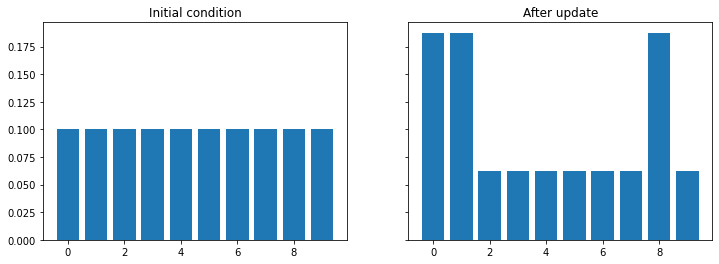

In [24]:
def update(hallway, belief, z, z_prob): 
    scale = z_prob / (1. - z_prob)  # 측정된 위치의 확률에 대한 scaling factor.
    belief[hallway==z] *= scale  # 측정 z를 이용하여 강아지가 있을 확률을 업데이트.
    normalize(belief)  # 강아지의 위치를 다시 확률로 normalize.


fig, ax = plt.subplots(1, 2, sharey=True, figsize=(12, 4))
    
hallway = np.array([1, 1, 0, 0, 0, 0, 0, 0, 1, 0])  # 문과 벽의 위치. 1은 문, 0은 벽.
belief = np.array([0.1]*10)  # 강아지의 위치에 대한 추정 (우리의 믿음). Initial condition.
ax[0].set_title("Initial condition")
ax[0].bar(np.arange(len(belief)), belief)

z = 1  # 센서로 측정된 값. 강아지 앞에 문이 있음
z_prob = 0.75  # 센서가 정확할 확률

update(hallway, belief, z, z_prob)  # 측정된 값을 이용하여 강아지의 위치 업데이트
ax[1].set_title("After update")
ax[1].bar(np.arange(len(belief)), belief)

- 사실 위 과정은 측정된 정보를(z) 이용하여 likelihood를 계산하고 이를 prior에(initial belief) 반영하여 posterior를 계산하는 과정입니다.
- 이를 나누어서 코드로 작성하면 다음과 같습니다.

<BarContainer object of 10 artists>

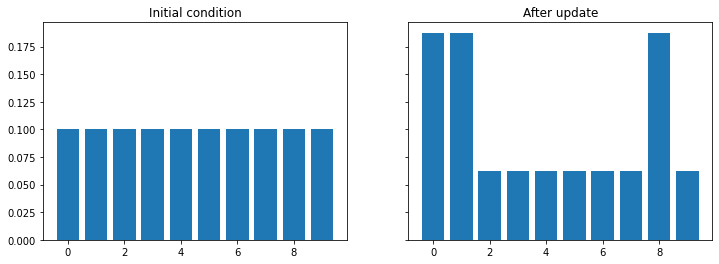

In [30]:
from filterpy.discrete_bayes import update  # 계산되 likelihood를 이용하여 


def lh_hallway(hall, z, z_prob):
    """ compute likelihood that a measurement matches
    positions in the hallway."""
    
    try:
        scale = z_prob / (1. - z_prob)
    except ZeroDivisionError:
        scale = 1e8

    likelihood = np.ones(len(hall))
    likelihood[hall==z] *= scale
    return likelihood


fig, ax = plt.subplots(1, 2, sharey=True, figsize=(12, 4))
    
hallway = np.array([1, 1, 0, 0, 0, 0, 0, 0, 1, 0])
belief = np.array([0.1]*10)

ax[0].set_title("Initial condition")
ax[0].bar(np.arange(len(belief)), belief)

likelihood = lh_hallway(hallway, z=1, z_prob=.75)
belief = update(likelihood, belief)

ax[1].set_title("After update")
ax[1].bar(np.arange(len(belief)), belief)

## Predict: 강아지의 움직임을 고려하여 다음 위치를 예측
- 센서에 오차가 없는 경우 단순히 belief array를 강아지의 움직임만큼 rollig하면 됩니다.
- 예를들어 강아지가 오른쪽으로 두 칸 이동한 경우 아래와 같이 확률이 수정됩니다.

<BarContainer object of 10 artists>

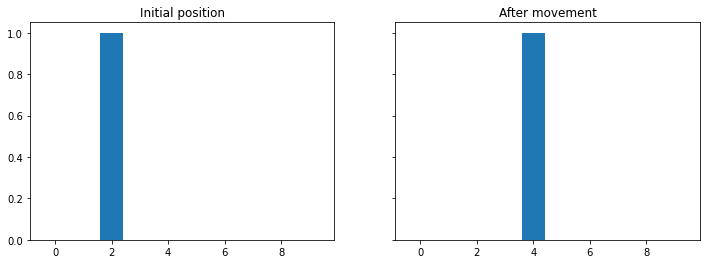

In [37]:
fig, ax = plt.subplots(1, 2, sharey=True, figsize=(12, 4))

belief = np.zeros(10)
belief[2] = 1
ax[0].set_title("Initial position")
ax[0].bar(np.arange(len(belief)), belief)

belief = np.roll(belief, 2)
ax[1].set_title("After movement")
ax[1].bar(np.arange(len(belief)), belief)

- 하지만 센서에 오차가 있는 경우 오차를 고려하여 강아지의 위치를 예측해야 합니다.

### 센서 오차를 고려하여 위치 예측
- 예를들어 강아지가 오른쪽으로 두 칸 이동했을 때 정말로 두 칸 이동했을 확률은 80%, 실제로는 한 칸 (overshoot) 또는 세 칸 (undershoot) 이동했을 확률을 10%라고 합니다.
- 이 경우 rolling 한 후 센서의 노이즈를 고려하면 강아지의 위치는 [0, 0, 0, 0.1, 0.8, 0.1, 0, ...] 이 됩니다.
- 이는 convolution을 이용하여 일반화 할 수 있습니다.
  1. 센서의 정확도를 이용하여 kernel을 만듭니다 -> [0.1, 0.8, 0.1]
  2. 강아지의 위치를 rolling하여 업데이트 합니다.
  3. kernel을 이용하여 convolution하여 강아지의 위치에 센서의 노이즈를 고려합니다.
- 이 과정을 코드로 나타내면 다음과 같습니다.

<BarContainer object of 12 artists>

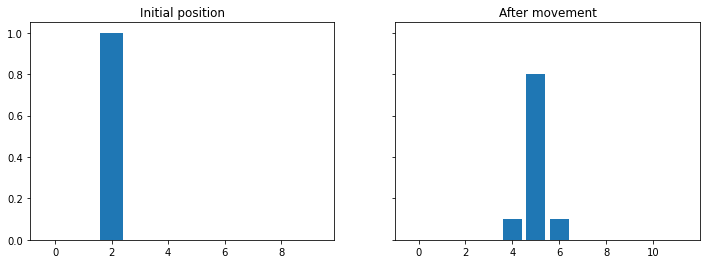

In [41]:
fig, ax = plt.subplots(1, 2, sharey=True, figsize=(12, 4))

belief = np.zeros(10)
belief[2] = 1
ax[0].set_title("Initial position")
ax[0].bar(np.arange(len(belief)), belief)

belief = np.roll(belief, 2)
belief = np.convolve(belief, [.1, .8, .1])
ax[1].set_title("After movement")
ax[1].bar(np.arange(len(belief)), belief)

## The Discrete Bayes Algorithm
<img src="imgs/predict_update.png">

- 지금까지의 내용을 그림으로 요약하면 위와 같습니다. Initial condition으로 주어진 belief($x_0$)를 관측($z_k$)을 이용하여 업데이트하고 다음 위치를 prediction 합니다.
- 수학적인 용어를 이용하여 설명하자면
  - Update step
    - $z_k$를 이용하여 likelihood 계산
    - Likelihood와 prior $x_{k-1}$를 이용하여 posterior 계산
  - Predict step
    - 다음 스탭의 위치 $\hat{x}_k$ 계산
    - $\hat{x}_k$를 이 다음 update에서 prior로 사용
    
$$\begin{aligned} \bar {\mathbf x} &= \mathbf x \ast f_{\mathbf x}(\bullet)\, \, &\text{Predict Step} \\
\mathbf x &= \|\mathcal L \cdot \bar{\mathbf x}\|\, \, &\text{Update Step}\end{aligned}$$

마지막으로 알고리즘을 정리하면 다음과 같습니다.

**Initialization**

    1. Initialize our belief in the state
    
**Predict**

    1. Based on the system behavior, predict state for the next time step
    2. Adjust belief to account for the uncertainty in prediction
    
**Update**

    1. Get a measurement and associated belief about its accuracy
    2. Compute how likely it is the measurement matches each state
    3. Update state belief with this likelihood